<a href="https://colab.research.google.com/github/nekokaito/deep-learning-rooftop-plant-health/blob/main/rooftop_plant_health_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving rooftop_plant_health.zip to rooftop_plant_health.zip


In [2]:
import zipfile
import os

zip_file = "rooftop_plant_health.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

dataset_path = "/content/dataset"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(indent + os.path.basename(root) + "/")

dataset/
  Dry_Severe_Damage/
  Healthy/
  Yellowing_Discoloration/
  Insect_Physical_Damage/
  Leaf_Spot_Browning/


In [4]:
import os

classes = [
    "Healthy",
    "Yellowing_Discoloration",
    "Leaf_Spot_Browning",
    "Dry_Severe_Damage",
    "Insect_Physical_Damage"
]

for class_name in classes:
    folder = os.path.join(dataset_path, class_name)

    if os.path.exists(folder):
        images = [
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        print(f"{class_name}: {len(images)} images")
    else:
        print(f"{class_name}: folder not found")

Healthy: 31 images
Yellowing_Discoloration: 10 images
Leaf_Spot_Browning: 13 images
Dry_Severe_Damage: 6 images
Insect_Physical_Damage: 4 images


In [9]:
import os
import shutil
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd


DATASET_DIR = Path("/content/dataset")


image_extensions = {".jpg", ".jpeg", ".png", ".webp"}


classes = [
    "Healthy",
    "Yellowing_Discoloration",
    "Leaf_Spot_Browning",
    "Dry_Severe_Damage",
    "Insect_Physical_Damage"
]

print("Setup completed!")

Setup completed!


In [10]:
OUTPUT_DIR = Path("/content/plant_dataset_split")


if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

for split in ["train", "validation", "test"]:
    for class_name in classes:
        (OUTPUT_DIR / split / class_name).mkdir(
            parents=True,
            exist_ok=True
        )

print("Folders created successfully!")

Folders created successfully!


In [12]:
random.seed(42)

for class_name in classes:

    class_dir = DATASET_DIR / class_name

    images = [
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in image_extensions
    ]


    random.shuffle(images)

    n = len(images)


    n_train = max(1, int(n * 0.70))
    n_val = max(1, int(n * 0.15))


    n_test = n - n_train - n_val

    if n_test < 1:
        n_test = 1
        n_train -= 1

    train_images = images[:n_train]
    val_images = images[n_train:n_train + n_val]
    test_images = images[n_train + n_val:]

    for image in train_images:
        shutil.copy2(
            image,
            OUTPUT_DIR / "train" / class_name / image.name
        )

    for image in val_images:
        shutil.copy2(
            image,
            OUTPUT_DIR / "validation" / class_name / image.name
        )

    for image in test_images:
        shutil.copy2(
            image,
            OUTPUT_DIR / "test" / class_name / image.name
        )

print("Dataset split completed!")

Dataset split completed!


In [13]:
for split in ["train", "validation", "test"]:

    print(f"\n===== {split.upper()} =====")

    total = 0

    for class_name in classes:

        folder = OUTPUT_DIR / split / class_name

        count = len([
            f for f in folder.iterdir()
            if f.is_file() and f.suffix.lower() in image_extensions
        ])

        total += count

        print(f"{class_name}: {count}")

    print("Total:", total)


===== TRAIN =====
Healthy: 21
Yellowing_Discoloration: 7
Leaf_Spot_Browning: 9
Dry_Severe_Damage: 4
Insect_Physical_Damage: 2
Total: 43

===== VALIDATION =====
Healthy: 4
Yellowing_Discoloration: 1
Leaf_Spot_Browning: 1
Dry_Severe_Damage: 1
Insect_Physical_Damage: 1
Total: 8

===== TEST =====
Healthy: 6
Yellowing_Discoloration: 2
Leaf_Spot_Browning: 3
Dry_Severe_Damage: 1
Insect_Physical_Damage: 1
Total: 13


In [14]:
records = []

for split in ["train", "validation", "test"]:

    for class_name in classes:

        folder = OUTPUT_DIR / split / class_name

        for image_file in folder.iterdir():

            if image_file.suffix.lower() in image_extensions:

                records.append({
                    "filename": image_file.name,
                    "class": class_name,
                    "split": split,
                    "path": str(image_file)
                })

split_df = pd.DataFrame(records)

print(split_df.head())
print("\nTotal records:", len(split_df))

                     filename    class  split  \
0  IMG_20260927_121257458.jpg  Healthy  train   
1  IMG_20260910_152732087.jpg  Healthy  train   
2  IMG_20260910_153058212.jpg  Healthy  train   
3  IMG_20260927_121446567.jpg  Healthy  train   
4  IMG_20260927_121138086.jpg  Healthy  train   

                                                path  
0  /content/plant_dataset_split/train/Healthy/IMG...  
1  /content/plant_dataset_split/train/Healthy/IMG...  
2  /content/plant_dataset_split/train/Healthy/IMG...  
3  /content/plant_dataset_split/train/Healthy/IMG...  
4  /content/plant_dataset_split/train/Healthy/IMG...  

Total records: 64


In [15]:
train_files = set(
    split_df[split_df["split"] == "train"]["filename"]
)

val_files = set(
    split_df[split_df["split"] == "validation"]["filename"]
)

test_files = set(
    split_df[split_df["split"] == "test"]["filename"]
)

print("Train ∩ Validation:", len(train_files & val_files))
print("Train ∩ Test:", len(train_files & test_files))
print("Validation ∩ Test:", len(val_files & test_files))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


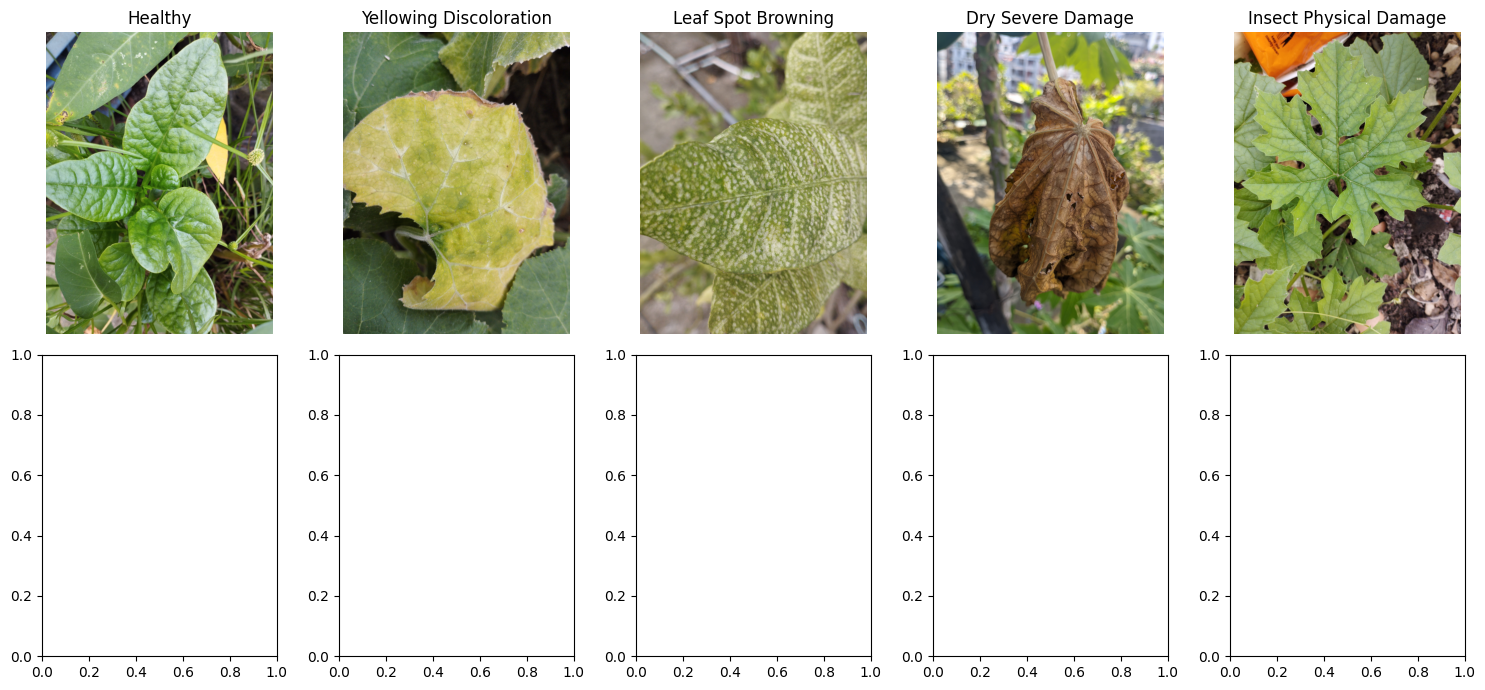

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

# Show sample images from the training set
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for ax, class_name in zip(axes[0], classes):
    folder = OUTPUT_DIR / "train" / class_name

    images = [
        f for f in folder.iterdir()
        if f.suffix.lower() in image_extensions
    ]

    if images:
        image = Image.open(images[0])
        ax.imshow(image)
        ax.set_title(class_name.replace("_", " "))

    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
image_sizes = []

for class_name in classes:
    folder = OUTPUT_DIR / "train" / class_name

    for image_file in folder.iterdir():
        if image_file.suffix.lower() in image_extensions:
            with Image.open(image_file) as img:
                image_sizes.append(img.size)

print("Number of images checked:", len(image_sizes))
print("First 10 image sizes:")
print(image_sizes[:10])

Number of images checked: 43
First 10 image sizes:
[(1536, 2048), (3060, 4080), (3060, 4080), (1536, 2048), (1536, 2048), (3060, 4080), (3060, 4080), (1536, 2048), (1536, 2048), (1536, 2048)]


In [19]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
SEED = 42

TensorFlow version: 2.20.0


In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [21]:
train_generator = train_datagen.flow_from_directory(
    OUTPUT_DIR / "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

validation_generator = val_test_datagen.flow_from_directory(
    OUTPUT_DIR / "validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    OUTPUT_DIR / "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 43 images belonging to 5 classes.
Found 8 images belonging to 5 classes.
Found 13 images belonging to 5 classes.


In [22]:
print(train_generator.class_indices)

{'Dry_Severe_Damage': 0, 'Healthy': 1, 'Insect_Physical_Damage': 2, 'Leaf_Spot_Browning': 3, 'Yellowing_Discoloration': 4}


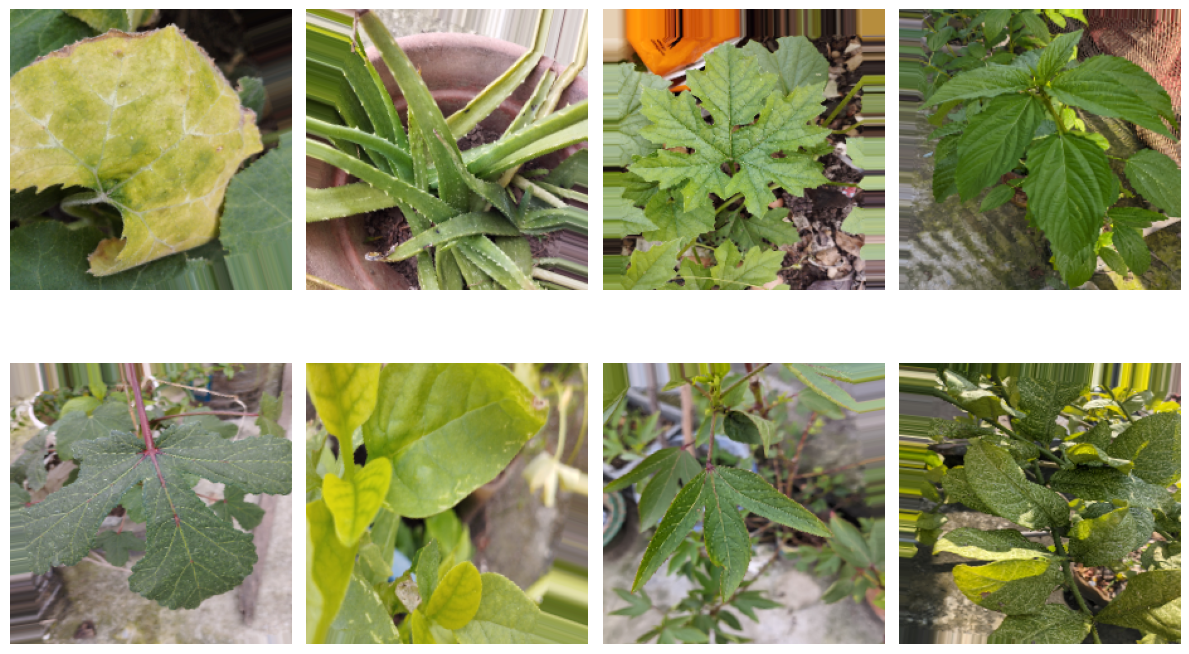

In [23]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

NUM_CLASSES = 5


base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


base_model.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
EPOCHS = 15

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1628 - loss: 2.1537 - val_accuracy: 0.3750 - val_loss: 1.6947
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 821ms/step - accuracy: 0.2326 - loss: 1.9688 - val_accuracy: 0.3750 - val_loss: 1.6568
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1628 - loss: 1.8831 - val_accuracy: 0.3750 - val_loss: 1.6356
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 759ms/step - accuracy: 0.2791 - loss: 1.7318 - val_accuracy: 0.5000 - val_loss: 1.6348
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 847ms/step - accuracy: 0.3023 - loss: 1.7868 - val_accuracy: 0.5000 - val_loss: 1.6383
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 908ms/step - accuracy: 0.3488 - loss: 1.7087 - val_accuracy: 0.5000 - val_loss: 1.6501
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 699ms/step - accuracy: 0.3256 - loss: 1.5243 - val_accuracy: 0.5000 - val_loss: 1.6648
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.4186 - loss: 1.4810 - val_accuracy: 0.5000 - val_loss: 1.6761


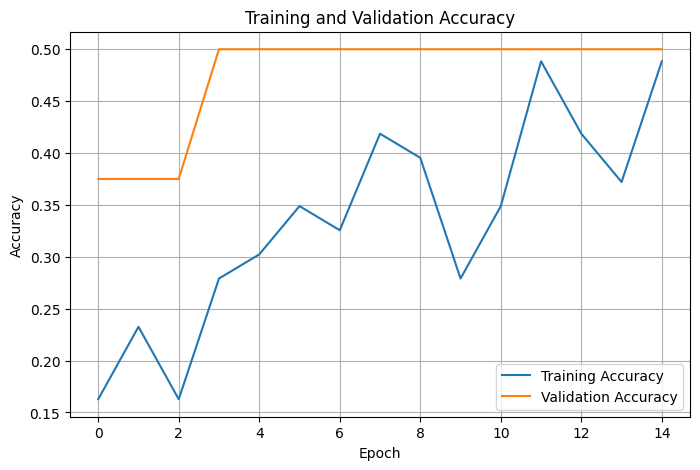

In [27]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

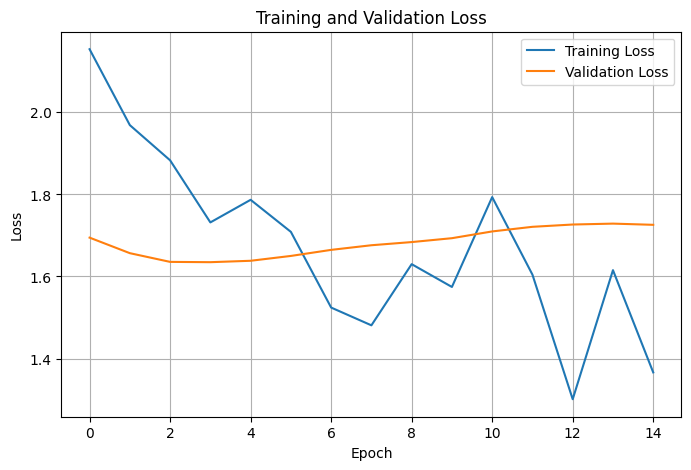

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.4615 - loss: 1.7034
Test Loss: 1.7034434080123901
Test Accuracy: 0.4615384638309479


In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Reset test generator
test_generator.reset()

predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names,
    zero_division=0
))

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step
                         precision    recall  f1-score   support

      Dry_Severe_Damage       0.00      0.00      0.00         1
                Healthy       0.46      1.00      0.63         6
 Insect_Physical_Damage       0.00      0.00      0.00         1
     Leaf_Spot_Browning       0.00      0.00      0.00         3
Yellowing_Discoloration       0.00      0.00      0.00         2

               accuracy                           0.46        13
              macro avg       0.09      0.20      0.13        13
           weighted avg       0.21      0.46      0.29        13



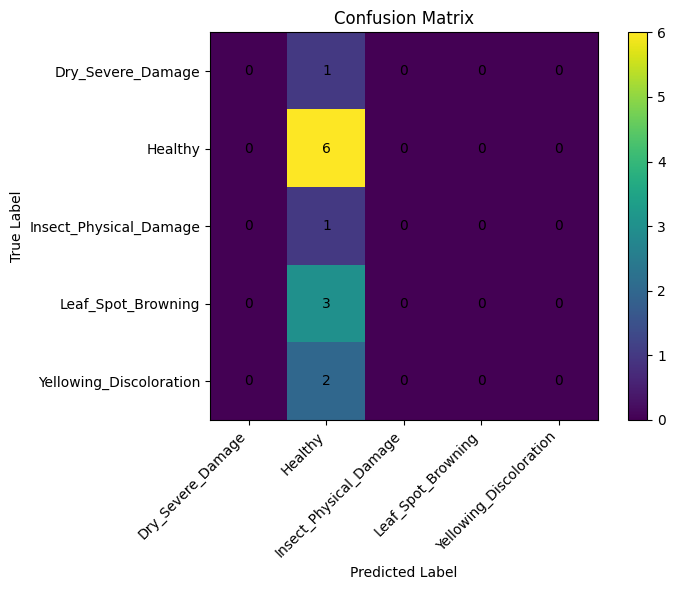

In [31]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()